# Flight Dataset — Visualization + NbPax Correlation
Saint-Exupery Airport | `database.db`

## 0. Import Libraries

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries ready')

Libraries ready


## 1. Load Data from database.db

In [4]:
_here = Path(os.getcwd())
DB_PATH = _here / 'database.db'
if not DB_PATH.exists():
    DB_PATH = _here / 'Procedure_data' / 'insa' / 'database.db'
if not DB_PATH.exists():
    DB_PATH = Path(r'C:\Users\ACER\Desktop\Flight Prediction\Procedure_data\insa\database.db')

print(f'DB path : {DB_PATH}')
print(f'Exists  : {DB_PATH.exists()}')

conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query('SELECT * FROM mouvements_aero_insa', conn)
conn.close()

df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'], errors='coerce')
df['Month']   = df['LTScheduledDatetime'].dt.to_period('M').astype(str)
df['Hour']    = df['LTScheduledDatetime'].dt.hour
df['Weekday'] = df['LTScheduledDatetime'].dt.day_name()

print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
df.head(2)

DB path : c:\Users\ACER\Desktop\Flight Prediction\Procedure_data\insa\database.db
Exists  : True
Loaded 364,623 rows x 198 columns


,IdMovementVinci,IdFarms,IdMovement,IdADL,IdPkgStand,IdTraficType,IdIrregularityCode,IdRunway,IdAircraftType,IdBusinessUnitType,...,PxScansAccPIF,PxScansPIF,PxScansRX,PxScansGAT,PxScansSalonConfluence,PxScansSalonMontblanc,etl_origin,Month,Hour,Weekday
0,NULL,NULL,20260701195500MAC00341,20260701195500MAC00341,NULL,2,NULL,NULL,320,1,...,NULL,NULL,NULL,NULL,NULL,NULL,Cohor,2026-07,19,Wednesday
1,NULL,NULL,20260422224500MAC00344,20260422224500MAC00344,NULL,2,NULL,NULL,320,1,...,NULL,NULL,NULL,NULL,NULL,NULL,Cohor,2026-04,22,Wednesday


## 2. Dataset Overview

In [3]:
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).to_string())
print('\n=== Numeric Statistics ===')
df.describe(include=[np.number]).round(2)

Rows    : 364,623
Columns : 198

=== Missing Values ===
Series([], )

=== Numeric Statistics ===


,IdTraficType,IdBusinessUnitType,IdBusContactType,IdTerminalType,IdBagStatusDelivery,NbFlight,Hour
count,364623.00,364623.00,364623.00,364623.00,364623.00,364623.0,364623.00
mean,1.12,1.25,2.08,0.92,2.31,1.0,13.92
std,0.42,1.09,1.09,0.27,0.95,0.0,5.15
min,0.00,1.00,0.00,0.00,1.00,1.0,0.00
25%,1.00,1.00,1.00,1.00,1.00,1.0,10.00
50%,1.00,1.00,3.00,1.00,3.00,1.0,14.00
75%,1.00,1.00,3.00,1.00,3.00,1.0,18.00
max,2.00,10.00,3.00,1.00,3.00,1.0,23.00


## 3. Arrivals vs Departures

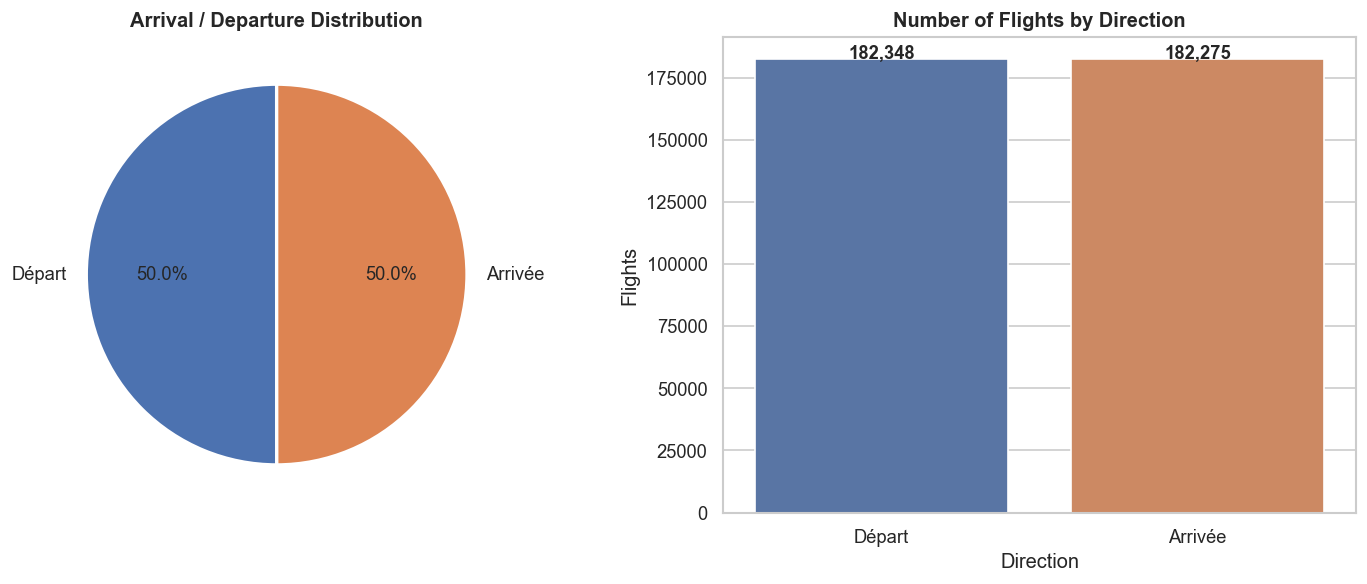

In [4]:
dir_counts = df['Direction'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(dir_counts, labels=dir_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Arrival / Departure Distribution', fontweight='bold')
sns.barplot(x=dir_counts.index, y=dir_counts.values,
            palette=['#4C72B0','#DD8452'], ax=axes[1])
axes[1].set_title('Number of Flights by Direction', fontweight='bold')
axes[1].set_xlabel('Direction'); axes[1].set_ylabel('Flights')
for i, v in enumerate(dir_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Top 15 Airlines

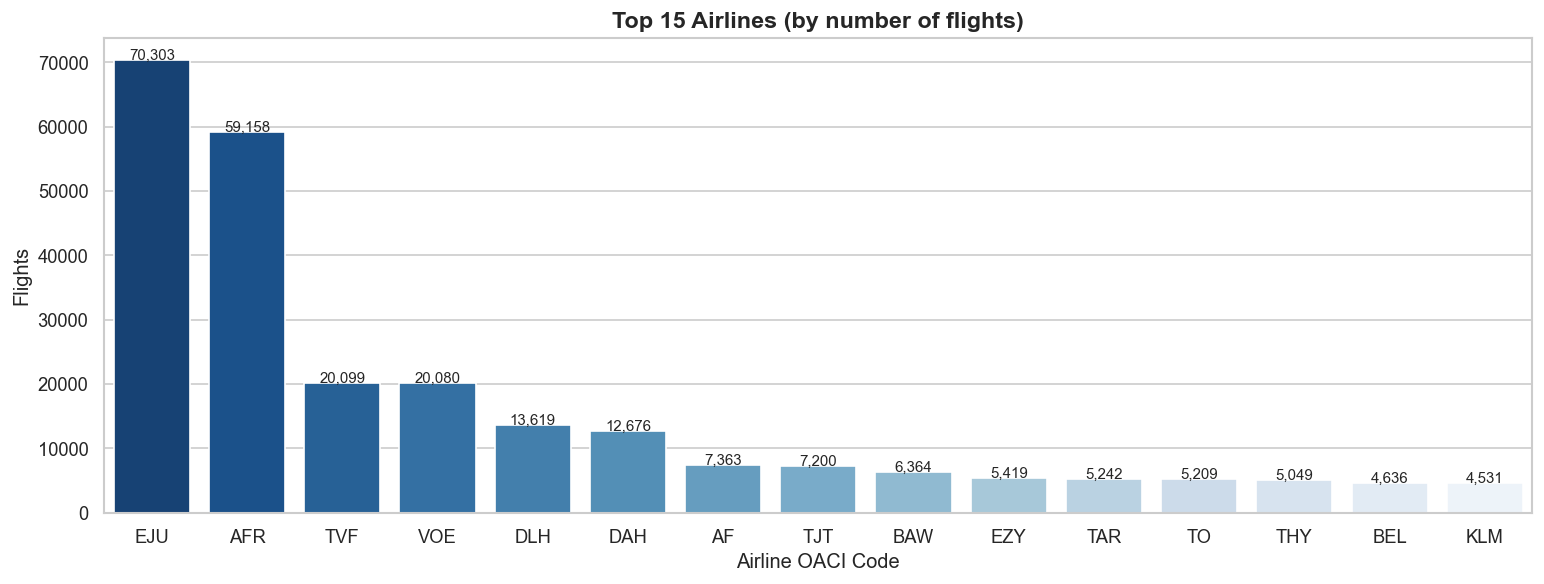

In [5]:
top_airlines = df['airlineOACICode'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(x=top_airlines.index, y=top_airlines.values, palette='Blues_r', ax=ax)
ax.set_title('Top 15 Airlines (by number of flights)', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline OACI Code'); ax.set_ylabel('Flights')
for i, v in enumerate(top_airlines.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Flights per Month

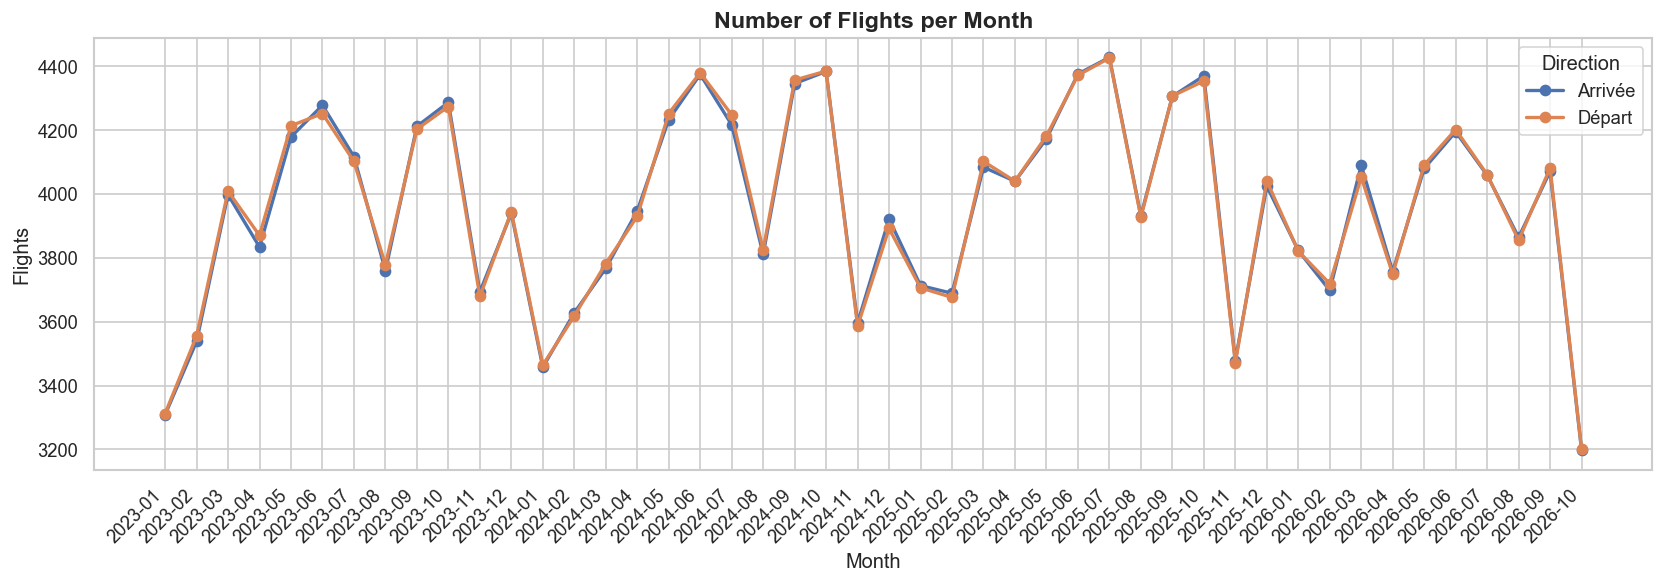

In [6]:
monthly = df.groupby(['Month','Direction']).size().reset_index(name='count').sort_values('Month')
fig, ax = plt.subplots(figsize=(14, 5))
for direction, grp in monthly.groupby('Direction'):
    ax.plot(grp['Month'], grp['count'], marker='o', label=direction, linewidth=2)
ax.set_title('Number of Flights per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Flights'); ax.legend(title='Direction')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 6. Flights by Hour of Day

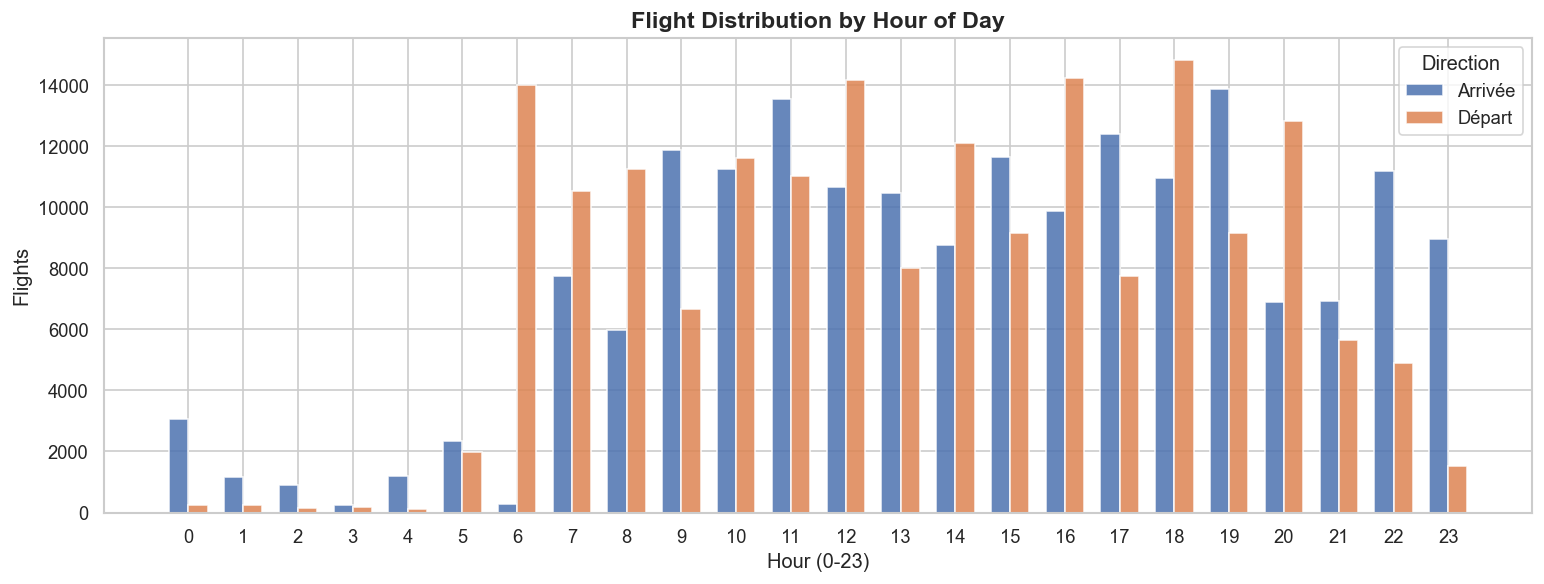

In [7]:
hourly = df.groupby(['Hour','Direction']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(13, 5))
directions = hourly['Direction'].unique()
offsets = {d: i*0.35 - 0.175 for i, d in enumerate(directions)}
for direction, grp in hourly.groupby('Direction'):
    ax.bar(grp['Hour'] + offsets[direction], grp['count'],
           width=0.35, label=direction, alpha=0.85)
ax.set_title('Flight Distribution by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (0-23)'); ax.set_ylabel('Flights'); ax.set_xticks(range(0,24))
ax.legend(title='Direction'); plt.tight_layout(); plt.show()

## 7. Distribution by Terminal

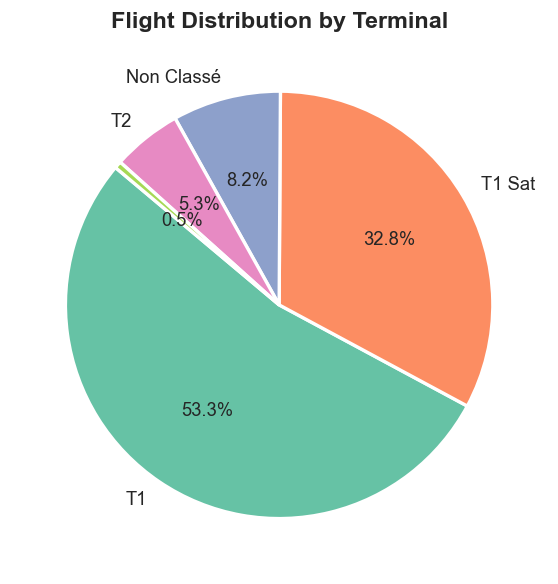

In [8]:
terminal_counts = df['Terminal'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.pie(terminal_counts, labels=terminal_counts.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('Set2', len(terminal_counts)),
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Flight Distribution by Terminal', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Top 15 Origin Airports

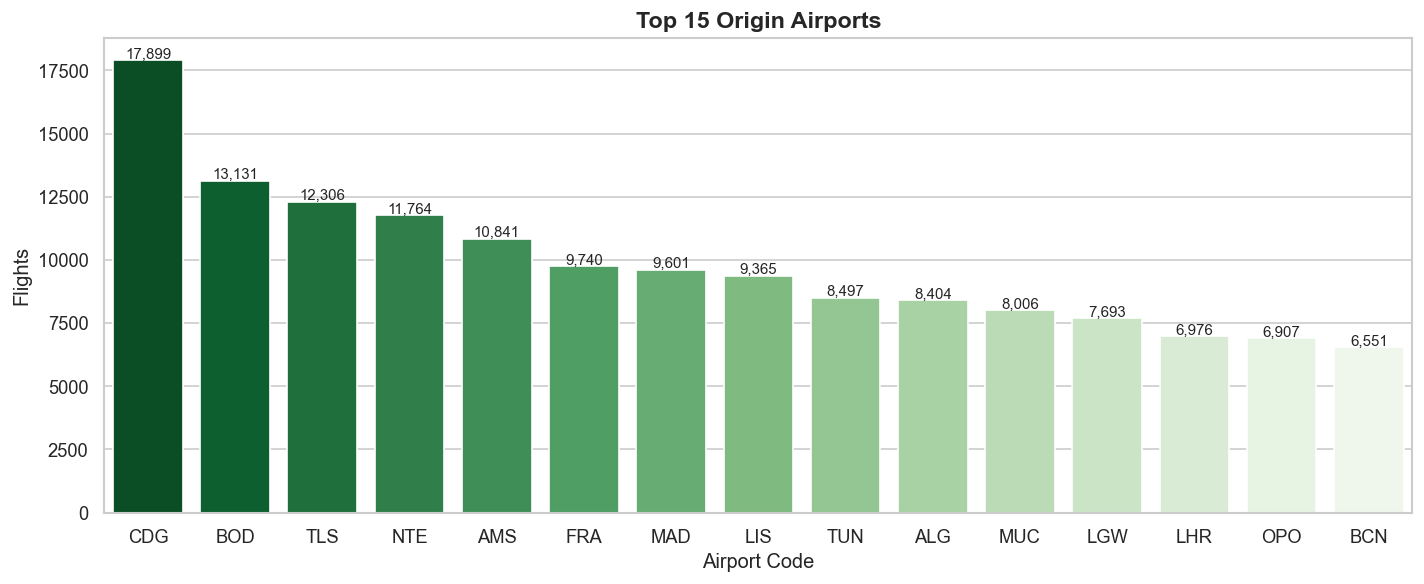

In [9]:
top_origins = df['AirportOrigin'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_origins.index, y=top_origins.values, palette='Greens_r', ax=ax)
ax.set_title('Top 15 Origin Airports', fontsize=14, fontweight='bold')
ax.set_xlabel('Airport Code'); ax.set_ylabel('Flights')
for i, v in enumerate(top_origins.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 9. Delay Analysis

Flights with delay: 52,991 / 364,623 (14.5%)


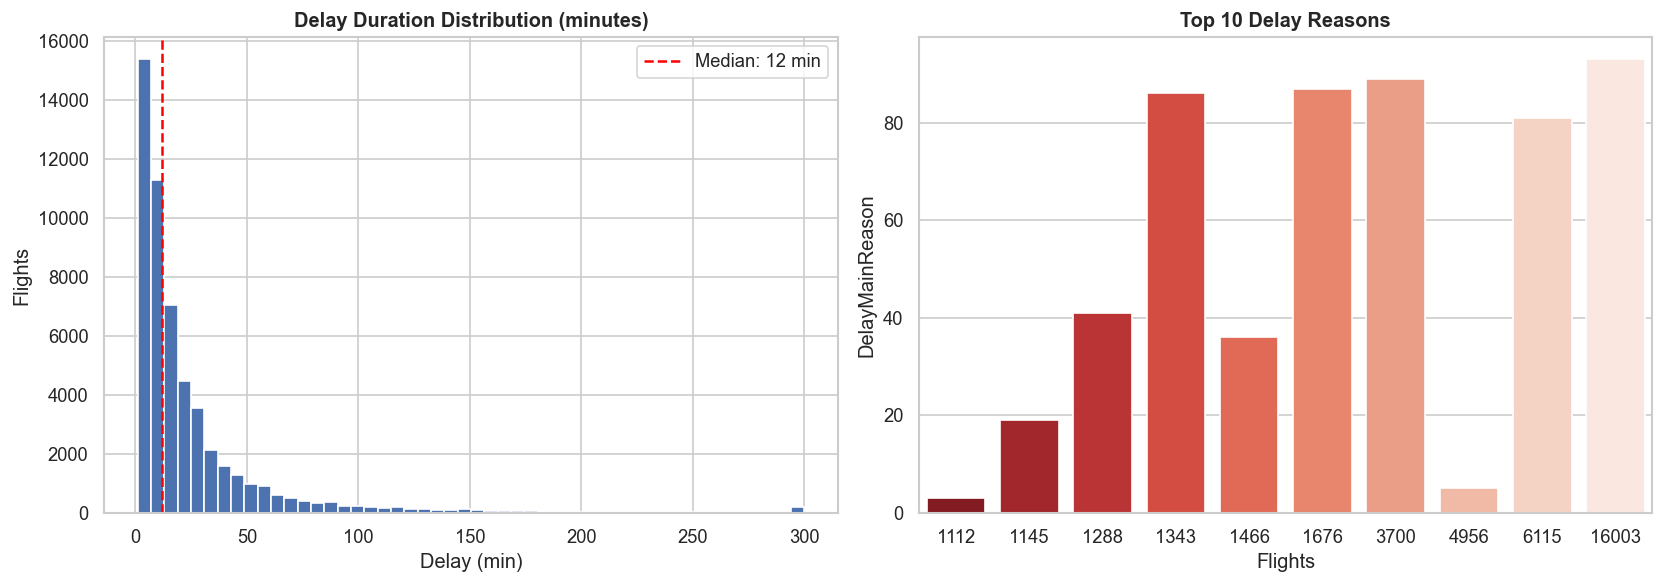

In [14]:
delay_col = "DelayMainReasonDuration"
# Convert to numeric (stored as string in DB)
df["_delay_num"] = pd.to_numeric(df[delay_col], errors="coerce")
df_delay = df[df["_delay_num"].notna() & (df["_delay_num"] > 0)].copy()
df_delay = df_delay.copy()
df_delay[delay_col] = df_delay["_delay_num"].astype(float)
print(f"Flights with delay: {len(df_delay):,} / {len(df):,} ({len(df_delay)/len(df)*100:.1f}%)")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_delay[delay_col].clip(upper=300), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Delay Duration Distribution (minutes)", fontweight="bold")
axes[0].set_xlabel("Delay (min)"); axes[0].set_ylabel("Flights")
axes[0].axvline(df_delay[delay_col].median(), color="red", linestyle="--",
                label=f"Median: {df_delay[delay_col].median():.0f} min")
axes[0].legend()
top_reasons = df_delay["DelayMainReason"].value_counts().head(10)
sns.barplot(y=top_reasons.index, x=top_reasons.values, palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 Delay Reasons", fontweight="bold")
axes[1].set_xlabel("Flights")
plt.tight_layout(); plt.show()

---
## 10. NbPax — Correlation with ALL Features
**When NbPaxTotal increases:** which features increase with it (green), which decrease (red)?
- **Numeric** → Pearson r ∈ [-1, +1]
- **Categorical** → Eta (ANOVA-based, signed)

### 10.1 Pearson — Numeric features

In [18]:
# Target column — always use NbPaxTotal
nbpax_col = "NbPaxTotal"
print(f"Target column: {nbpax_col}")

df_clean = df.dropna(subset=[nbpax_col]).copy()

# Force numeric types — pandas 3 Arrow backend fix
for _c in df_clean.columns:
    try:
        conv = pd.to_numeric(df_clean[_c], errors="coerce")
        if conv.notna().mean() > 0.8:
            df_clean[_c] = conv
    except Exception:
        pass

df_clean[nbpax_col] = pd.to_numeric(df_clean[nbpax_col], errors="coerce")
df_clean = df_clean.dropna(subset=[nbpax_col])
print(f"Rows with {nbpax_col} not null: {len(df_clean):,}")

# --- PEARSON: numeric features ---
num_cols = [c for c in df_clean.columns
            if c != nbpax_col and pd.api.types.is_numeric_dtype(df_clean[c])]

pearson_results = {}
for col in num_cols:
    tmp = df_clean[[nbpax_col, col]].dropna()
    if len(tmp) < 30:
        continue
    try:
        x = tmp[nbpax_col].astype(float).to_numpy()
        y = tmp[col].astype(float).to_numpy()
        r, p = stats.pearsonr(x, y)
        pearson_results[col] = {"correlation": round(r, 4), "p_value": p,
                                "type": "Numeric (Pearson)", "n": len(tmp)}
    except Exception as e:
        print(f"  Skip {col}: {e}")

df_pearson = pd.DataFrame(pearson_results).T.astype({"correlation": float, "p_value": float})
df_pearson["significant"] = df_pearson["p_value"] < 0.05
print(f"Numeric features analysed: {len(df_pearson)}")
df_pearson.sort_values("correlation", ascending=False)

Target column: NbPaxTotal
Rows with NbPaxTotal not null: 311,036
Numeric features analysed: 38


,correlation,p_value,type,n,significant
InvoiceNbPaxTotal,1.0000,0.000000e+00,Numeric (Pearson),293480,True
NbPaxHTransit,0.9972,0.000000e+00,Numeric (Pearson),311036,True
InvoiceNbPaxHTransit,0.9967,0.000000e+00,Numeric (Pearson),293480,True
NbPax,0.9896,0.000000e+00,Numeric (Pearson),311036,True
InvoiceNbPayingPax,0.9881,0.000000e+00,Numeric (Pearson),293480,True
FarmsNbPax,0.8817,0.000000e+00,Numeric (Pearson),311036,True
FarmsNbPaxHTransit,0.8662,0.000000e+00,Numeric (Pearson),311036,True
FarmsNbPaxTotal,0.8652,0.000000e+00,Numeric (Pearson),311036,True
InvoiceNbOfSeats,0.7958,0.000000e+00,Numeric (Pearson),293414,True
NbOfSeats,0.6663,0.000000e+00,Numeric (Pearson),310722,True


### 10.2 Eta — Categorical features

In [19]:
def eta_correlation(series_cat, series_num):
    tmp = pd.DataFrame({'cat': series_cat, 'num': series_num}).dropna()
    if len(tmp) < 30 or tmp['cat'].nunique() < 2:
        return None, None, None
    groups = [g['num'].values for _, g in tmp.groupby('cat')]
    f_stat, p = stats.f_oneway(*groups)
    grand_mean = tmp['num'].mean()
    ss_total   = ((tmp['num'] - grand_mean) ** 2).sum()
    if ss_total == 0:
        return None, None, None
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    eta = np.sqrt(ss_between / ss_total)
    group_means = tmp.groupby('cat')['num'].mean()
    tmp2 = tmp.copy(); tmp2['cat_rank'] = tmp2['cat'].map(group_means)
    sign = np.sign(np.corrcoef(tmp2['cat_rank'], tmp2['num'])[0, 1])
    return sign * eta, p, len(tmp)

skip_cols = ['Month', 'Weekday', 'LTScheduledDatetime']
cat_cols = [c for c in df_clean.select_dtypes(include=['object','category']).columns
            if c not in skip_cols]

eta_results = {}
for col in cat_cols:
    eta, p, n = eta_correlation(df_clean[col], df_clean[nbpax_col])
    if eta is not None:
        eta_results[col] = {'correlation': round(eta, 4), 'p_value': p,
                            'type': 'Categorical (Eta)', 'n': n}

df_eta = pd.DataFrame(eta_results).T.astype({'correlation': float, 'p_value': float})
df_eta['significant'] = df_eta['p_value'] < 0.05
print(f'Categorical features analysed: {len(df_eta)}')
df_eta.sort_values('correlation', ascending=False)

Categorical features analysed: 150


,correlation,p_value,type,n,significant
IdMovementVinci,0.9999,9.016888e-01,Categorical (Eta),311036,False
IdADL,0.9995,0.000000e+00,Categorical (Eta),311036,True
IdMovement,0.9986,0.000000e+00,Categorical (Eta),311036,True
LTRunwayDatetime,0.9829,0.000000e+00,Categorical (Eta),311036,True
UTCRunwayDatetime,0.9829,0.000000e+00,Categorical (Eta),311036,True
...,...,...,...,...,...
TurnsBlockNightStop,0.0658,5.431710e-294,Categorical (Eta),311036,True
TurnAircraftSwap,0.0655,1.788930e-291,Categorical (Eta),311036,True
BusCauseModif,0.0316,3.783942e-59,Categorical (Eta),311036,True
Direction,0.0057,1.344353e-03,Categorical (Eta),311036,True


### 10.3 Merge & Print Ranking

In [13]:
df_all = pd.concat([df_pearson, df_eta]).sort_values('correlation', ascending=False)
df_all['direction'] = df_all['correlation'].apply(
    lambda x: 'Increases with NbPax' if x > 0 else 'Decreases when NbPax increases')

print(f'Total features ranked: {len(df_all)}')
print('\n=== TOP features that INCREASE with NbPax (POSITIVE correlation) ===')
print(df_all[df_all['correlation'] > 0][['correlation','significant','type','direction']].to_string())
print('\n=== TOP features that DECREASE when NbPax increases (NEGATIVE correlation) ===')
print(df_all[df_all['correlation'] < 0][['correlation','significant','type','direction']].sort_values('correlation').to_string())

Total features ranked: 188

=== TOP features that INCREASE with NbPax (POSITIVE correlation) ===
                                       correlation  significant               type             direction
InvoiceNbPayingPax                          1.0000         True  Numeric (Pearson)  Increases with NbPax
IdMovementVinci                             0.9999        False  Categorical (Eta)  Increases with NbPax
IdADL                                       0.9995         True  Categorical (Eta)  Increases with NbPax
IdMovement                                  0.9987         True  Categorical (Eta)  Increases with NbPax
NbPaxHTransit                               0.9923         True  Numeric (Pearson)  Increases with NbPax
InvoiceNbPaxHTransit                        0.9912         True  Numeric (Pearson)  Increases with NbPax
NbPaxTotal                                  0.9896         True  Numeric (Pearson)  Increases with NbPax
InvoiceNbPaxTotal                           0.9881         True

### 10.3b NbPax Mean & Distribution by Category Values

For each top categorical feature (ranked by Eta correlation), show **mean NbPax** per category value — avoids bias from unequal record counts.

Plotting 15 categorical features:
['InvoiceFlightKindCode', 'GateGroup', 'flight_with_pax', 'BagAssistant', 'RunwayAssistant', 'InvoiceADLSecurityGroups', 'IdPkgStand', 'DeskZone', 'Terminal', 'InvoiceAirportBasedCode', 'FarmsTerminal', 'ServiceCode', 'NbConveyor', 'InvoiceStand400HtzIndicator', 'InvoiceEnergyUseIndicator']


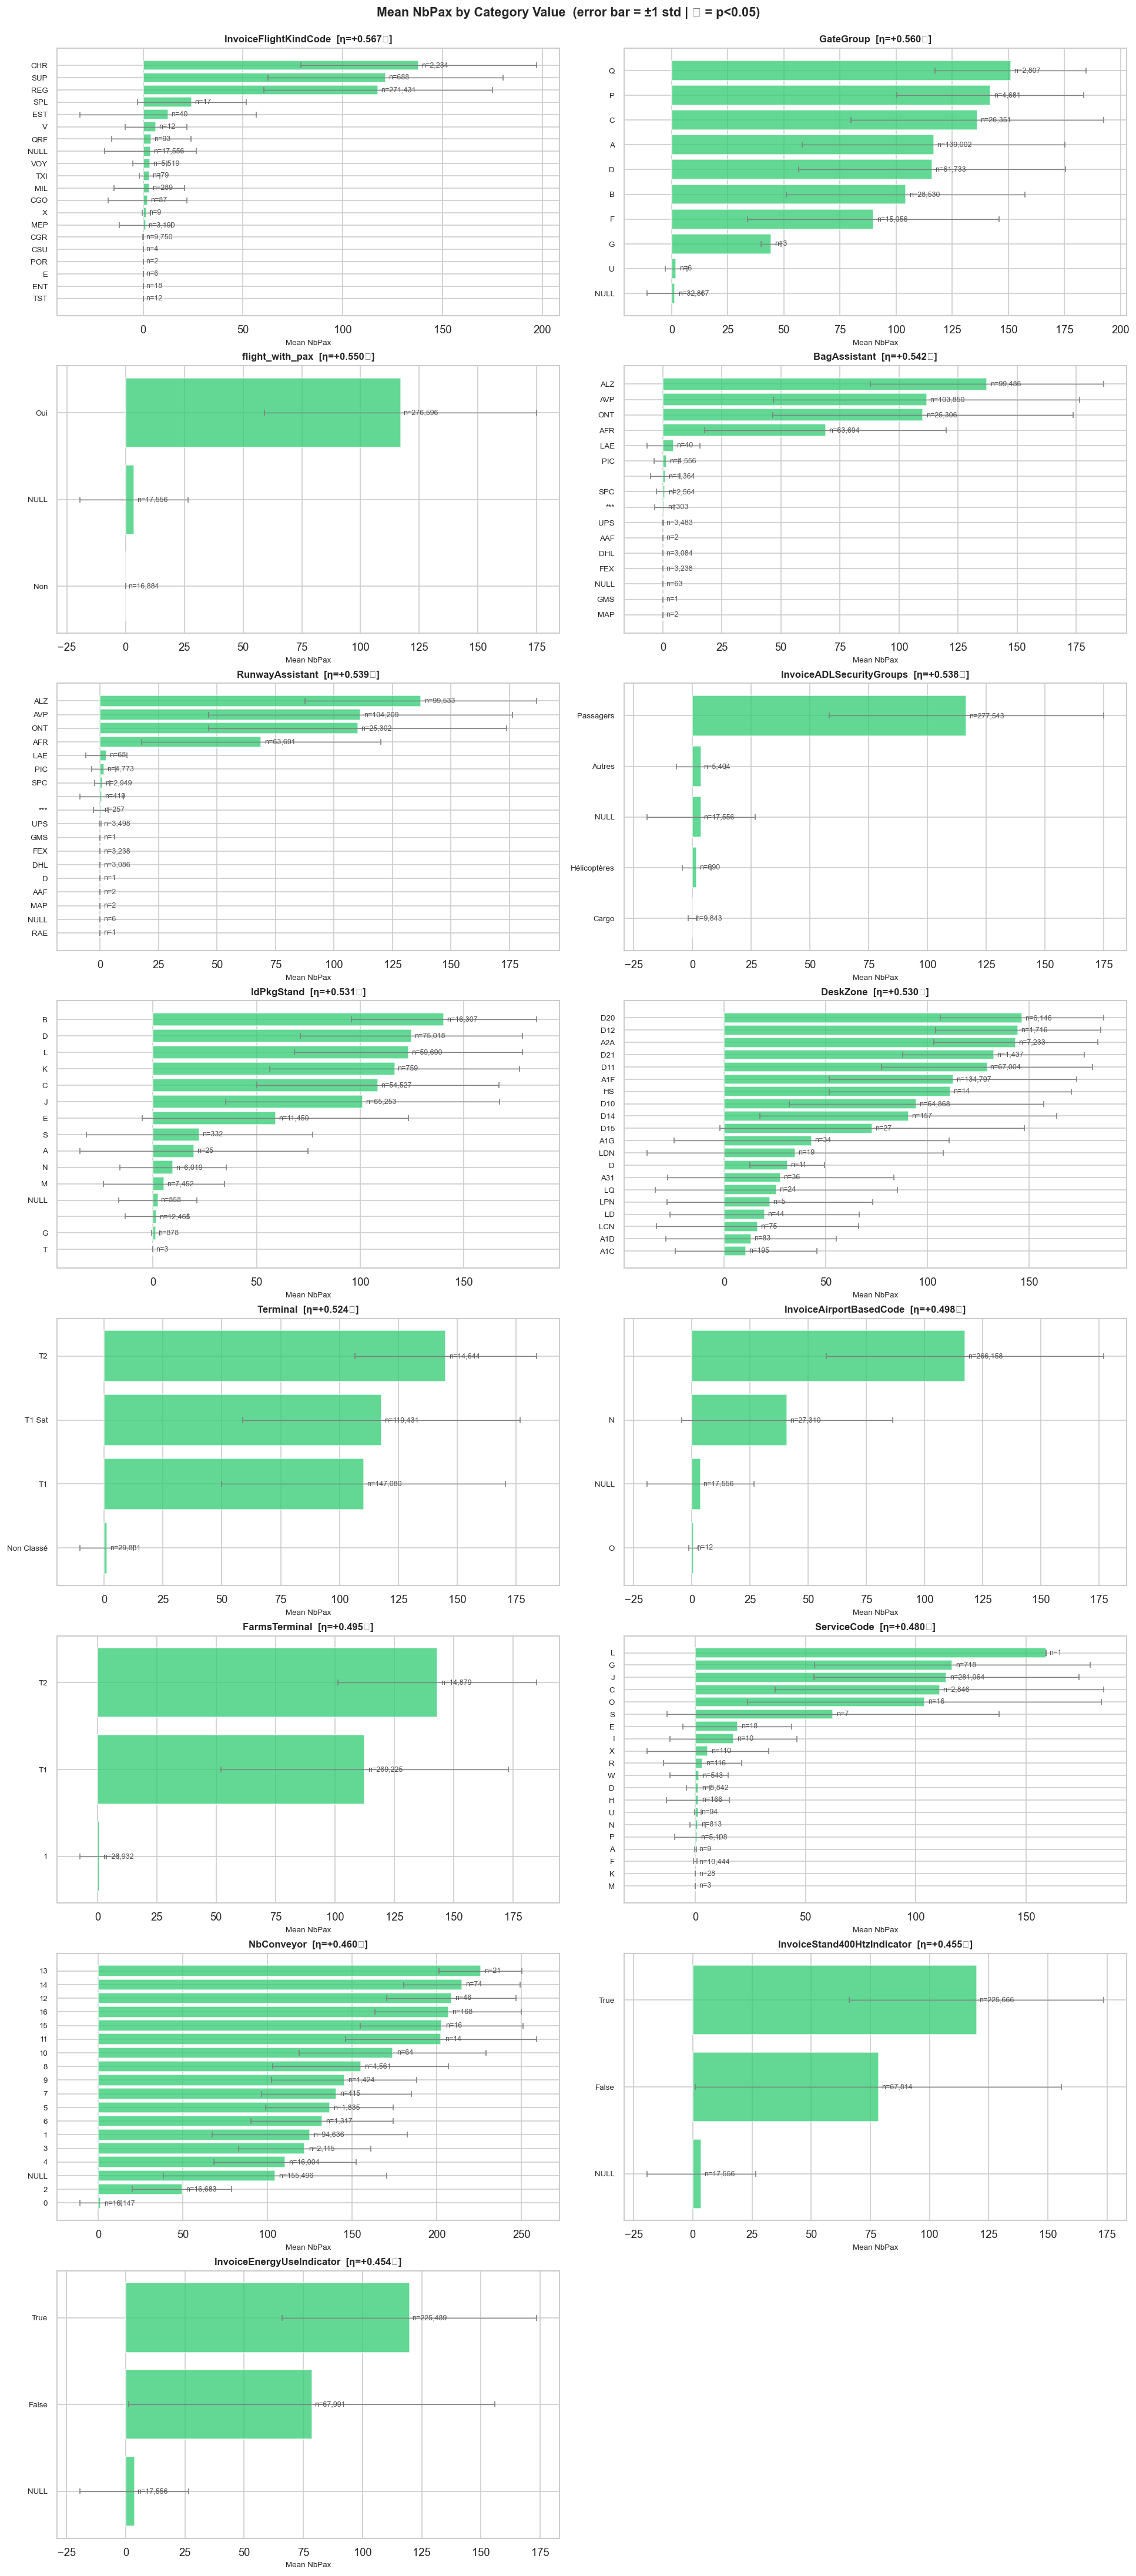

In [14]:
# --- NbPax Mean & Distribution per Category Value ---
# Select top categorical features by eta (skip columns with too many unique values)
MAX_UNIQUE   = 40   # skip features with > 40 unique values (too granular)
TOP_N_FEAT   = 15   # plot only top 15 features by |eta|
TOP_N_VAL    = 20   # per feature, show only top 20 values by count

top_cat_features = (
    df_eta
    .sort_values('correlation', ascending=False, key=abs)
    .index
    .tolist()
)

# Filter by MAX_UNIQUE
top_cat_features = [
    c for c in top_cat_features
    if c in df_clean.columns and df_clean[c].nunique() <= MAX_UNIQUE
][:TOP_N_FEAT]

print(f"Plotting {len(top_cat_features)} categorical features:")
print(top_cat_features)

n_feat  = len(top_cat_features)
n_cols  = 2
n_rows  = (n_feat + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(16, n_rows * 4.5),
                         constrained_layout=True)
axes = axes.flatten()

for i, feat in enumerate(top_cat_features):
    ax = axes[i]

    # Group by category value → compute mean & count
    grp = (
        df_clean.groupby(feat)[nbpax_col]
        .agg(mean_pax='mean', count='count', std_pax='std')
        .reset_index()
        .sort_values('mean_pax', ascending=False)
        .head(TOP_N_VAL)
    )

    eta_val  = df_eta.loc[feat, 'correlation'] if feat in df_eta.index else 0
    sig_flag = df_eta.loc[feat, 'significant'] if feat in df_eta.index else False
    sig_star = "★" if sig_flag else ""

    colors_bar = ['#2ecc71' if eta_val >= 0 else '#e74c3c'] * len(grp)

    bars = ax.barh(
        grp[feat].astype(str),
        grp['mean_pax'],
        xerr=grp['std_pax'].fillna(0),
        color=colors_bar,
        alpha=0.75,
        edgecolor='white',
        error_kw=dict(ecolor='gray', capsize=3, linewidth=0.8)
    )

    # Annotate bars with sample count
    for bar, cnt in zip(bars, grp['count']):
        ax.text(bar.get_width() + grp['mean_pax'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"n={cnt:,}", va='center', ha='left', fontsize=7.5, color='#555')

    ax.set_title(f"{feat}  [η={eta_val:+.3f}{sig_star}]",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f"Mean {nbpax_col}", fontsize=8)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Mean {nbpax_col} by Category Value  (error bar = ±1 std | ★ = p<0.05)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.show()

### 10.4 Plot 1 — Ranked Bar Chart (all features)

In [ ]:
# PLOT 1: Ranked Bar Chart
fig, ax = plt.subplots(figsize=(14, max(6, len(df_all) * 0.42)))
colors = ['#27ae60' if (v > 0 and s) else '#a9dfbf' if v > 0
          else '#e74c3c' if s else '#f1948a'
          for v, s in zip(df_all['correlation'], df_all['significant'])]

bars = ax.barh(df_all.index[::-1], df_all['correlation'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel(f'Correlation with {nbpax_col}', fontsize=12)
ax.set_title(f'Feature Correlation Ranking — {nbpax_col}\n'
             '(Dark=significant p<0.05 | Green=positive | Red=negative)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, df_all['correlation'][::-1]):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8.5)
plt.tight_layout(); plt.show()

### 10.5 Plot 2 — Heatmap (top numeric)

In [ ]:
# PLOT 2: Heatmap — top numeric features
top_numeric = df_pearson['correlation'].abs().sort_values(ascending=False).head(12).index.tolist()
heat_cols   = [nbpax_col] + top_numeric
heat_df     = df_clean[heat_cols].dropna()
corr_matrix = heat_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title(f'Correlation Heatmap — {nbpax_col} & Top Numeric Features',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()

### 10.6 Plot 3 — Scatter plots (top 6 numeric)

In [ ]:
# PLOT 3: Scatter plots — top 6 numeric
top6 = df_pearson['correlation'].abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10)); axes = axes.flatten()
for i, col in enumerate(top6):
    valid = df_clean[[nbpax_col, col]].dropna()
    r = df_pearson.loc[col, 'correlation']
    color = '#27ae60' if r > 0 else '#e74c3c'
    axes[i].scatter(valid[col], valid[nbpax_col], alpha=0.2, s=8, color=color)
    m, b = np.polyfit(valid[col], valid[nbpax_col], 1)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 200)
    axes[i].plot(x_line, m*x_line+b, color='black', linewidth=1.5,
                 linestyle='--', label=f'r = {r:+.3f}')
    axes[i].set_xlabel(col, fontsize=9); axes[i].set_ylabel(nbpax_col, fontsize=9)
    axes[i].set_title(f'{nbpax_col} vs {col}', fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=9)
plt.suptitle(f'Scatter Plots — {nbpax_col} vs Top 6 Numeric Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 10.7 Plot 4 — Box plots (top 4 categorical)

In [ ]:
# PLOT 4: Box plots — top 4 categorical
top4_cat = df_eta['correlation'].abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 11)); axes = axes.flatten()
for i, col in enumerate(top4_cat):
    valid = df_clean[[nbpax_col, col]].dropna()
    top_cats = valid[col].value_counts().head(12).index
    valid = valid[valid[col].isin(top_cats)]
    order = valid.groupby(col)[nbpax_col].median().sort_values(ascending=False).index
    r = df_eta.loc[col, 'correlation']
    sns.boxplot(data=valid, x=col, y=nbpax_col, order=order,
                palette='Blues', ax=axes[i], showfliers=False)
    axes[i].set_title(f'{nbpax_col} by {col}  (eta={r:+.3f})',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel(col, fontsize=9); axes[i].set_ylabel(nbpax_col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=35)
plt.suptitle(f'{nbpax_col} vs Top 4 Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 10.8 Summary Table

In [16]:
# SUMMARY TABLE
df_summary = df_all[['correlation','p_value','significant','type']].copy()
df_summary['|corr|'] = df_summary['correlation'].abs().round(4)
df_summary['direction'] = df_summary['correlation'].apply(
    lambda x: 'Increases with NbPax' if x > 0 else 'Decreases when NbPax increases')
df_summary = df_summary.sort_values('correlation', ascending=False)
df_summary.index.name = 'feature'
print(f'FULL RANKING — {len(df_summary)} features vs {nbpax_col}')
print(df_summary[['correlation','|corr|','direction','significant','type']].to_string())

FULL RANKING — 188 features vs NbPax
                                       correlation  |corr|                       direction  significant               type
feature                                                                                                                   
InvoiceNbPayingPax                          1.0000  1.0000            Increases with NbPax         True  Numeric (Pearson)
IdMovementVinci                             0.9999  0.9999            Increases with NbPax        False  Categorical (Eta)
IdADL                                       0.9995  0.9995            Increases with NbPax         True  Categorical (Eta)
IdMovement                                  0.9987  0.9987            Increases with NbPax         True  Categorical (Eta)
NbPaxHTransit                               0.9923  0.9923            Increases with NbPax         True  Numeric (Pearson)
InvoiceNbPaxHTransit                        0.9912  0.9912            Increases with NbPax         Tru

In [17]:
# Export feature ranking to CSV
csv_path = Path(os.getcwd()) / 'csv_export' / 'feature_ranking_nbpax.csv'
csv_path.parent.mkdir(parents=True, exist_ok=True)

df_export = df_summary[['correlation', '|corr|', 'p_value', 'significant', 'type', 'direction']].copy()
df_export.index.name = 'feature'
df_export.to_csv(csv_path)

print(f"✅ Saved {len(df_export)} features → {csv_path}")

✅ Saved 188 features → c:\Users\ACER\Desktop\Flight Prediction\Procedure_data\insa\csv_export\feature_ranking_nbpax.csv


---
## 11. Feature Engineering

### Decision basis (from actual dataset columns):

| Raw Column | unique | Action | Reason |
|---|---|---|---|
| `LTScheduledDatetime` | 209k | ✅ Extract | Source of all temporal features |
| `Direction` | 2 | ✅ Keep | Direct signal |
| `IdTraficType` | 3 | ✅ Keep | Direct signal |
| `Terminal` | 4 | ✅ Keep | Direct signal |
| `airlineOACICode` | 470 | 🔧 Encode | Too many → target-encode + LCC flag |
| `IdAircraftType` | 346 | 🔧 Encode | Numeric ID → mean NbPax per type |
| `AirportOrigin` | high | 🔧 Encode | Route-level mean NbPax |
| `DelayMainReasonDuration` | — | ❌ DROP | **Post-flight → data leakage** |
| `DelayMainReason` | — | ❌ DROP | **Post-flight → data leakage** |
| `TaxiDurationMinutes` | — | ❌ DROP | **Post-flight → data leakage** |
| `TurnsBlockTimeMinutes` | — | ❌ DROP | 72% missing + post-flight |

### 11.1 Drop leakage columns

In [ ]:
# Start from df_clean (rows where NbPax is not null)
df_fe = df_clean.copy()

# Drop post-flight columns → data leakage if used to predict NbPax before flight
LEAKAGE_COLS = [
    'DelayMainReasonDuration', 'DelayMainReason',
    'TaxiDurationMinutes', 'TurnsBlockTimeMinutes',
    '_delay_num',           # internal helper column
]
dropped = [c for c in LEAKAGE_COLS if c in df_fe.columns]
df_fe.drop(columns=dropped, inplace=True)
print(f"Dropped {len(dropped)} leakage columns: {dropped}")
print(f"Shape after drop: {df_fe.shape}")

### 11.2 Temporal features (from `LTScheduledDatetime`)

In [ ]:
dt = df_fe['LTScheduledDatetime']

# Month of year (numeric 1-12)
df_fe['MonthOfYear']  = dt.dt.month

# Season (Northern Hemisphere)
df_fe['Season'] = dt.dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Day of week (0=Monday … 6=Sunday)
df_fe['DayOfWeek'] = dt.dt.dayofweek

# Is weekend (Saturday=5, Sunday=6)
df_fe['IsWeekend'] = (df_fe['DayOfWeek'] >= 5).astype(int)

# Time slot (bins of the day)
df_fe['TimeSlot'] = pd.cut(
    dt.dt.hour,
    bins=[-1, 5, 11, 16, 20, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late']
)

# French public holidays (fixed + approximate recurring dates)
FRENCH_HOLIDAYS = {
    (1, 1), (5, 1), (5, 8), (7, 14), (8, 15),
    (11, 1), (11, 11), (12, 25),
    # Easter Monday, Ascension, Whit Monday vary by year — approximated:
    (4, 18), (5, 29), (6, 9),
}
df_fe['IsHoliday'] = dt.apply(
    lambda x: int((x.month, x.day) in FRENCH_HOLIDAYS) if pd.notna(x) else 0
)

print("Temporal features created:")
print(df_fe[['Season','MonthOfYear','DayOfWeek','IsWeekend','TimeSlot','IsHoliday']].head(4))

### 11.3 Airline features (target encoding + LCC flag)

In [ ]:
# --- AirlineMeanPax: leave-one-out target encoding ---
# Uses grand mean as fallback for unseen airlines (no leakage)
grand_mean = df_fe[nbpax_col].mean()
airline_stats = df_fe.groupby('airlineOACICode')[nbpax_col].agg(['sum', 'count'])
airline_stats.columns = ['_sum', '_cnt']

# LOO: mean of ALL OTHER rows in same group
df_fe['AirlineMeanPax'] = df_fe.apply(
    lambda row: (
        (airline_stats.loc[row['airlineOACICode'], '_sum'] - row[nbpax_col]) /
        max(airline_stats.loc[row['airlineOACICode'], '_cnt'] - 1, 1)
    ) if row['airlineOACICode'] in airline_stats.index else grand_mean,
    axis=1
)

# --- AirlineFlightCount: frequency of airline in dataset ---
airline_freq = df_fe['airlineOACICode'].value_counts()
df_fe['AirlineFlightCount'] = df_fe['airlineOACICode'].map(airline_freq)

# --- IsLowCost: known European LCC OACI codes ---
LCC_CODES = {
    'EZY', 'RYR', 'VLG', 'IBE', 'VOE', 'HV',   # easyJet, Ryanair, Vueling, Iberia, Volotea, Transavia
    'TOM', 'MON', 'TCX', 'EXS', 'BEE', 'BAW',   # TUI, etc.
    'W6',  'FR',  'U2',  'FB',  'PS',            # IATA codes sometimes used
}
df_fe['IsLowCost'] = df_fe['airlineOACICode'].isin(LCC_CODES).astype(int)

print("Airline features created:")
print(df_fe[['airlineOACICode','AirlineMeanPax','AirlineFlightCount','IsLowCost']].head(4))
print(f"\nAirlineMeanPax range: {df_fe['AirlineMeanPax'].min():.1f} – {df_fe['AirlineMeanPax'].max():.1f}")

### 11.4 Route features (from `AirportOrigin`)

In [ ]:
origin_col = 'AirportOrigin' if 'AirportOrigin' in df_fe.columns else None

if origin_col:
    # --- RouteMeanPax: LOO target encoding per (AirportOrigin, Direction) ---
    route_key = df_fe[[origin_col, 'Direction']].astype(str).agg('|'.join, axis=1)
    df_fe['_route_key'] = route_key

    route_stats = df_fe.groupby('_route_key')[nbpax_col].agg(['sum', 'count'])
    route_stats.columns = ['_rsum', '_rcnt']

    df_fe['RouteMeanPax'] = df_fe.apply(
        lambda row: (
            (route_stats.loc[row['_route_key'], '_rsum'] - row[nbpax_col]) /
            max(route_stats.loc[row['_route_key'], '_rcnt'] - 1, 1)
        ) if row['_route_key'] in route_stats.index else grand_mean,
        axis=1
    )

    # --- RouteFrequency: how often this route appears ---
    df_fe['RouteFrequency'] = df_fe['_route_key'].map(df_fe['_route_key'].value_counts())

    # --- IsInternational: French airports start with 'LF', others are international ---
    # ICAO: French airports = 'LF...' prefix; IATA: French domestic = known list
    FRENCH_IATA = {
        'CDG','ORY','NCE','LYS','MRS','TLS','BOD','NTE','LIL','SXB',
        'MLH','MPL','RNS','BIQ','CFE','AJA','BIA','FSC','CLY','DIJ',
        'BES','LIG','GNB','LRH','PUF','BZR','ETZ','XCR','LDE','DNR',
        'VAF','PIS','LVA','CMF','QXB','LSO'
    }
    if origin_col in df_fe.columns:
        df_fe['IsInternational'] = (~df_fe[origin_col].isin(FRENCH_IATA)).astype(int)

    df_fe.drop(columns=['_route_key'], inplace=True)
    print("Route features created:")
    print(df_fe[['AirportOrigin','RouteMeanPax','RouteFrequency','IsInternational']].head(4))
else:
    print("AirportOrigin column not found — skipping route features")

### 11.5 Aircraft features (from `IdAircraftType`)

In [ ]:
# IdAircraftType is a numeric ID (346 distinct) → target encode as mean NbPax per type
ac_stats = df_fe.groupby('IdAircraftType')[nbpax_col].agg(['sum', 'count'])
ac_stats.columns = ['_asum', '_acnt']

df_fe['AircraftMeanPax'] = df_fe.apply(
    lambda row: (
        (ac_stats.loc[row['IdAircraftType'], '_asum'] - row[nbpax_col]) /
        max(ac_stats.loc[row['IdAircraftType'], '_acnt'] - 1, 1)
    ) if row['IdAircraftType'] in ac_stats.index else grand_mean,
    axis=1
)

print("Aircraft features created:")
print(df_fe[['IdAircraftType','AircraftMeanPax']].describe())

### 11.6 Final feature set summary

In [ ]:
FINAL_FEATURES = [
    # --- Keep raw ---
    'Direction', 'IdTraficType', 'Terminal',
    # --- Temporal (engineered) ---
    'MonthOfYear', 'Season', 'DayOfWeek', 'IsWeekend', 'TimeSlot', 'IsHoliday',
    # --- Airline (engineered) ---
    'AirlineMeanPax', 'AirlineFlightCount', 'IsLowCost',
    # --- Route (engineered) ---
    'RouteMeanPax', 'RouteFrequency', 'IsInternational',
    # --- Aircraft (engineered) ---
    'AircraftMeanPax',
]

# Keep only features that exist in df_fe
available = [f for f in FINAL_FEATURES if f in df_fe.columns]
missing_f  = [f for f in FINAL_FEATURES if f not in df_fe.columns]

df_model = df_fe[available + [nbpax_col]].copy()

print(f"✅ Final model dataset: {df_model.shape[0]:,} rows × {len(available)} features + 1 target")
print(f"\nFeatures ({len(available)}):")
for f in available:
    dtype = df_model[f].dtype
    nu    = df_model[f].nunique()
    miss  = df_model[f].isna().sum()
    print(f"  {f:<28} dtype={str(dtype):<12} unique={nu:<6} missing={miss}")
if missing_f:
    print(f"\n⚠️  Not available (column missing from DB): {missing_f}")

df_model.head(3)